In [64]:
import os
import io
import warnings
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import Perceptron
from sklearn.metrics import hinge_loss
from sklearn.metrics import ConfusionMatrixDisplay , confusion_matrix , precision_recall_curve
from sklearn.metrics import precision_score , recall_score , classification_report
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate , cross_val_predict , GridSearchCV
from pprint import pprint

import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
X , y = fetch_openml('mnist_784' , version=1 , return_X_y=True)

In [66]:
X = X.to_numpy()
y = y.to_numpy()

In [67]:
target_names = np.unique(y)
print(f"Number Of Samlpes: {X.shape[0]} , type: {X.dtype}")
print(f"Number of features: {X.shape[1]}")
print(f"Maximum:{np.max(X)} , Minimum:{np.min(X)}")
print(f"Number of classes:{len(target_names)} , type:{y.dtype}")
print(f"Labels:{target_names}")


Number Of Samlpes: 70000 , type: int64
Number of features: 784
Maximum:255 , Minimum:0
Number of classes:10 , type:object
Labels:['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [68]:
X = MinMaxScaler().fit_transform(X)
print(f"Minimum:{np.min(X)} , Maximum:{np.max(X)}")

Minimum:0.0 , Maximum:1.0


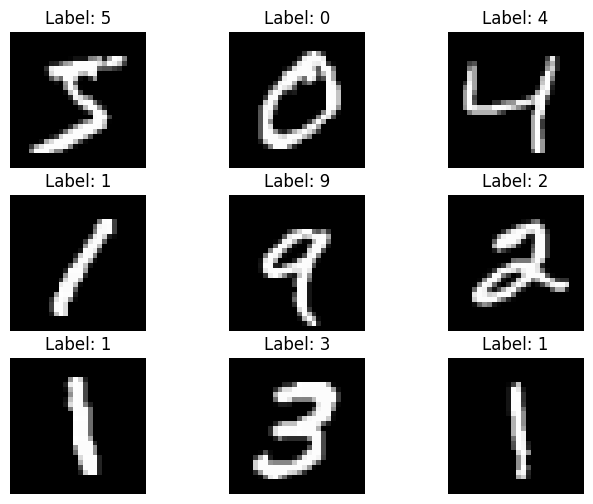

In [69]:
num_images = 9 # Choose a square number
factor = np.int64(np.sqrt(num_images))
fig,ax = plt.subplots(nrows=factor,ncols=factor,figsize=(8,6))
idx_offset = 0 # take "num_images" starting from the index "idx_offset"
for i in range(factor):
    index = idx_offset+i*(factor)
    for j in range(factor) :
        ax[i,j].imshow(X[index+j].reshape(28,28) , cmap='gray')
        ax[i, j].set_title('Label: {0}'.format (str(y[ index+j] ) ) )
        ax[i,j].set_axis_off()

In [70]:
x_train, x_test, y_train, y_test = X[:60000 ], X[ 60000 : ] , y[ : 60000 ] , y[ 60000 : ]

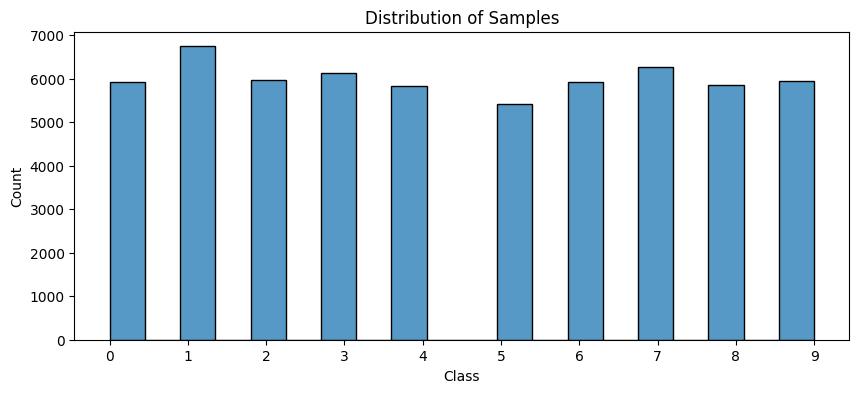

In [71]:
plt.figure(figsize=(10,4))
sns.histplot(data=np.int8(y_train),binwidth=0.45,bins=11)
plt.xticks(ticks=[0,1,2,3,4,5,6,7,8,9],labels=[0,1,2,3,4,5,6,7,8,9])
plt.xlabel('Class')
plt.title('Distribution of Samples')
plt.show()

### Binary Classification : 0-Detector

In [72]:
y_train_0 = -1*(np.ones(len(y_train)))
y_test_0 = -1*(np.ones(len(y_test)))

index_0 = np.where(y_train=='0')
y_train_0[index_0] = 1

index_0 = np.where(y_test=='0')
y_test_0[index_0] = 1

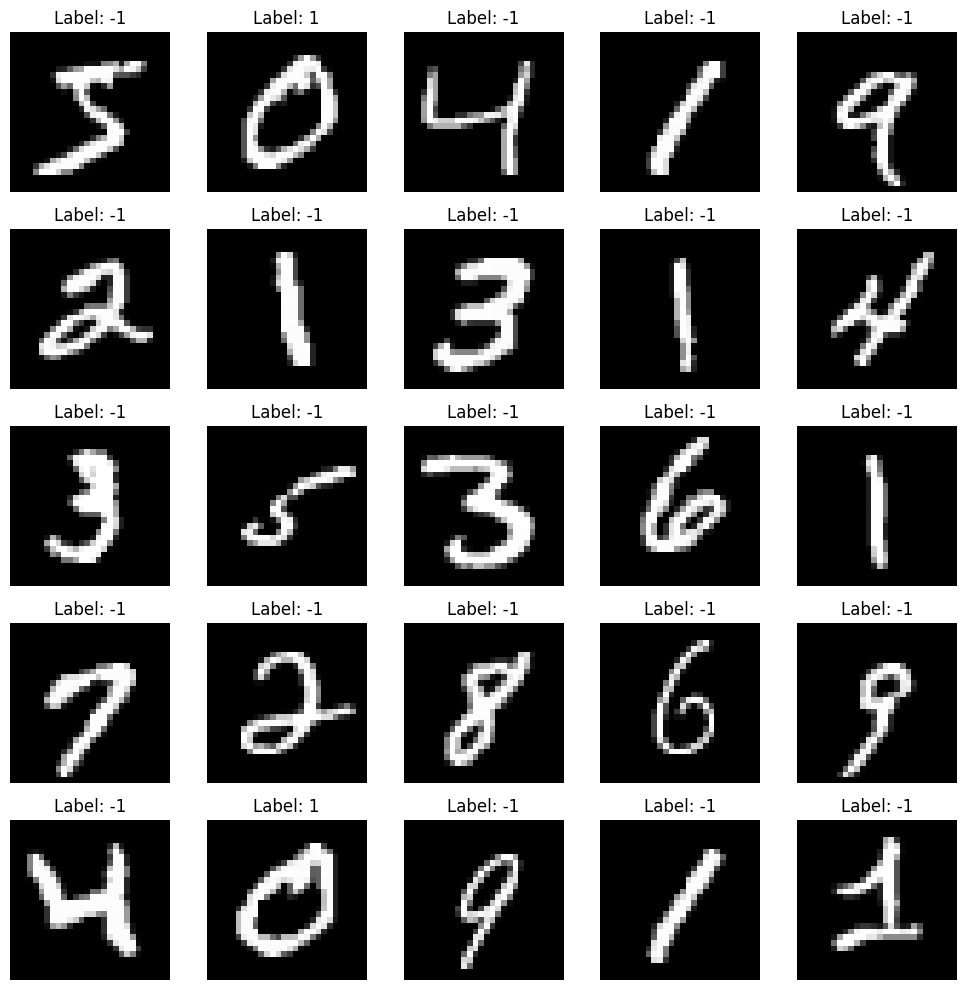

In [73]:
import matplotlib.pyplot as plt

# Variables set karein (agar pehle se nahi kiye hain)
factor = 5
idx_offset = 0

# 1. Canvas aur Grid setup karna (5x5 ka grid banayega)
fig, ax = plt.subplots(factor, factor, figsize=(10, 10))

# 2. Aapka logic (Images ko grid mein dalne ke liye)
for i in range(factor):
    index = idx_offset + i * factor
    for j in range(factor):
        # Dhyaan dein: Agar aapka data X_train mein hai, toh yahan X_train likhein
        ax[i, j].imshow(X[index + j].reshape(28, 28), cmap='gray')
        
        # Label set karna
        label_val = int(y_train_0[index + j])
        ax[i, j].set_title('Label: {0}'.format(label_val))
        
        # Axes/lines hide karna
        ax[i, j].set_axis_off()

# Space ko thoda clean karne ke liye (Optional but recommended)
plt.tight_layout()

# 3. SABSE ZAROORI STEP: Plot ko screen par show karna
plt.show()

In [74]:
num_pos = len(np.where(y_train_0==1)[0])
num_neg = len(np.where(y_train_0==-1)[0])
print(num_pos,num_neg)

5923 54077


In [75]:
base_clf = DummyClassifier(strategy="most_frequent")

In [76]:
base_clf.fit(x_train , y_train_0)
print(f"training Accuracy : {base_clf.score(x_train , y_train_0):.3f}")
print(f"Testing Accuracy : {base_clf.score(x_test , y_test_0):.3f}")

training Accuracy : 0.901
Testing Accuracy : 0.902


class sklearn.linear_model.Perceptron(*, 
    penalty=None, alpha=0.0001, 11_ratio=0.15, 
    fit_intercept=True, max_iter=1000, tol=0.001, 
    shuffle=True, verbose=0, eta0=1.0, 
    n_jobs=None, random_state=0,
    early_stopping=False, validation_fraction=0.1, n_iter_no_change=5, 
    class_weight=None, warm start=False)

In [77]:
bin_clf = Perceptron(max_iter=1000 , random_state=1729)

In [78]:
bin_clf.fit(x_train , y_train_0)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",1729


In [79]:
print(f"Dimentions of wights: {bin_clf.coef_.shape[1]}")
print(f"Bias : {bin_clf.intercept_}")
print(f"The Loss Function : {bin_clf.loss}")

Dimentions of wights: 784
Bias : [-108.]
The Loss Function : perceptron


In [80]:
y_hat_train_0 = bin_clf.predict(x_train)
print(f"Training Accuracy: {bin_clf.score(x_train,y_train_0)}")

Training Accuracy: 0.99095


In [81]:
y_hat_test_0 = bin_clf.predict(x_test)
print(f"Test Accuracy : {bin_clf.score(x_test,y_test_0)}")

Test Accuracy : 0.989


#### Displaying Prediction

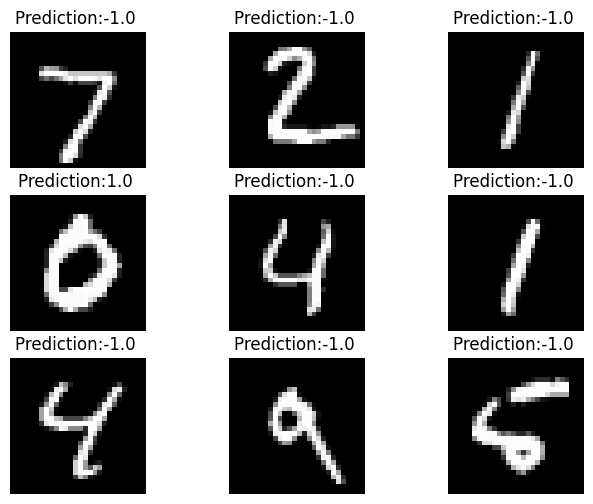

In [82]:
y_hat_test_0 = bin_clf.predict(x_test)
num_images = 9 # Choose a square number
factor = np.int64(np.sqrt(num_images))
fig, ax = plt.subplots(nrows=factor,ncols=factor,figsize=(8,6))
idx_offset = 0 # display "num_images" starting from idx_offset
for i in range(factor) :
    index = idx_offset+i*(factor)
    for j in range(factor) :
        ax[i, j] . imshow(x_test[ index+j] .reshape(28, 28) , cmap='gray') # we should not use x_train_with
        ax[i, j].set_title('Prediction:{0} '.format(str(y_hat_test_0[ index+j] ) ) )
        ax[i, j].set_axis_off()

In [83]:
index_0 = np.where(y_test_0==1)

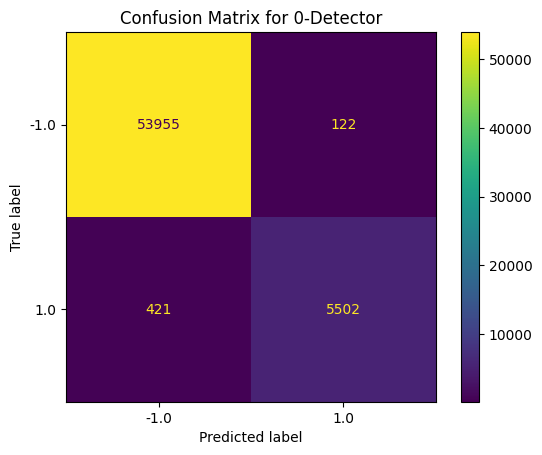

In [84]:
# 1. Model se predictions nikalna (Yeh line aapki bilkul sahi hai)
y_hat_train_0 = bin_clf.predict(x_train) # Dhyan rakhein, standard convention mein isse X_train likhte hain

# 2. Confusion Matrix banana aur display karna
# Yahan hum x_train ki jagah y_train_0 (True Labels) use karenge
cm_display = ConfusionMatrixDisplay.from_predictions(y_train_0, y_hat_train_0, values_format='.5g')

# 3. Graph show karna
plt.title("Confusion Matrix for 0-Detector")
plt.show()

#### Precision and Recall

In [85]:
cf_matrix = cm_display.confusion_matrix
tn = cf_matrix[0,0]
fn = cf_matrix[1,0]
fp = cf_matrix[0,1]
tp = cf_matrix[1,1]

precision = tp/(tp+fp)
print('Precision: ',precision)
recall= tp/(tp+fn)
print('Recall: ',recall)
accuracy = (tn+tp)/(tn+tp+fn+fp)
print( 'Accuracy: ',accuracy)

Precision:  0.9783072546230441
Recall:  0.9289211548201924
Accuracy:  0.99095


#### Cross Validation

In [86]:
bin_clf = Perceptron(max_iter=1000 , random_state=1729)
scores = cross_validate(
    bin_clf,
    x_train,y_train_0,
    cv=5,
    scoring=['precision','recall','f1'],
    return_estimator=True
)
pprint(scores)

{'estimator': [Perceptron(random_state=1729),
               Perceptron(random_state=1729),
               Perceptron(random_state=1729),
               Perceptron(random_state=1729),
               Perceptron(random_state=1729)],
 'fit_time': array([0.53303409, 1.16132545, 0.67303276, 0.63641596, 0.75263476]),
 'score_time': array([0.01200366, 0.01052213, 0.0110054 , 0.0130105 , 0.01101208]),
 'test_f1': array([0.95238095, 0.91666667, 0.94915254, 0.94117647, 0.95091763]),
 'test_precision': array([0.95890411, 0.98828125, 0.95319149, 0.95090439, 0.96200345]),
 'test_recall': array([0.94594595, 0.85472973, 0.94514768, 0.93164557, 0.94008439])}


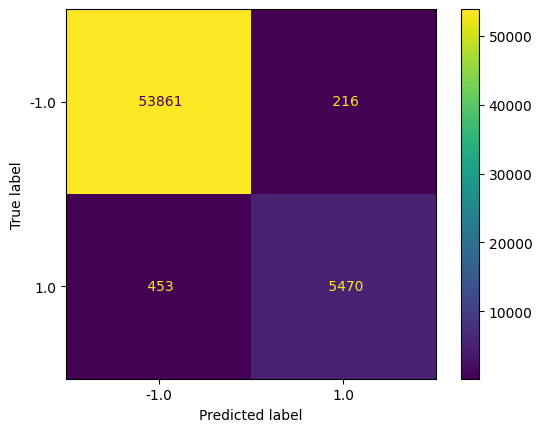

In [89]:
y_hat_train_0 = cross_val_predict(bin_clf, x_train, y_train_0, cv=5)
cm_display = ConfusionMatrixDisplay.from_predictions(y_train_0, y_hat_train_0, values_format=' .5g')
plt.show()

In [88]:
cf_matrix = cm_display.confusion_matrix
tn = cf_matrix[0,0]
fn = cf_matrix[1,0]
fp = cf_matrix[0,1]
tp = cf_matrix[1,1]

precision = tp/(tp+fp)
print('Precision: %.2f'%precision)
recall = tp/(tp+fn)
print('Recall: %.2f' %recall)
f1= 2/((1/precision)+(1/recall))
print('f1:%.2f' %f1)
accuracy = (tn+tp)/(tn+tp+fn+fp)
print('Accuracy: %.2f' %accuracy)

Precision: 0.96
Recall: 0.92
f1:0.94
Accuracy: 0.99


#### Precision/Recall Tradeoff

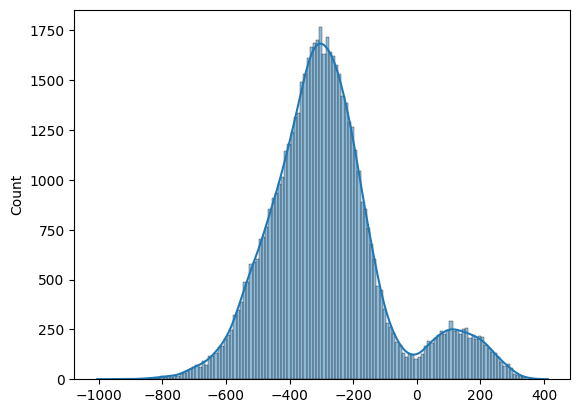

In [92]:
bin_clf = Perceptron(random_state=1729)
bin_clf.fit(x_train , y_train_0)
y_scores = bin_clf.decision_function(x_train)
sns.histplot(np.sort(y_scores) , kde=True)
plt.show()

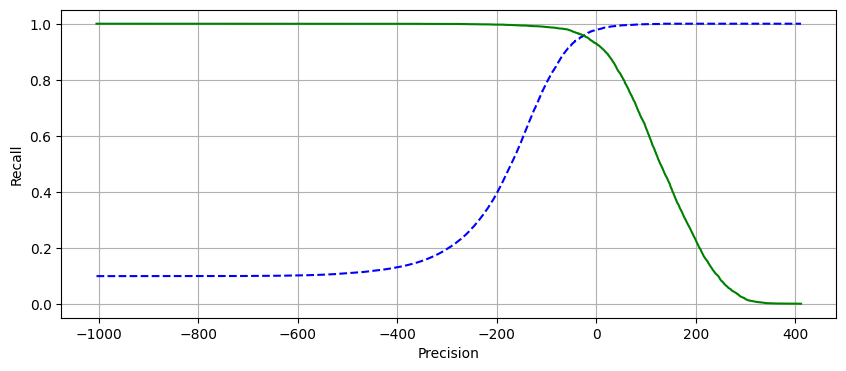

In [95]:
precisions, recalls, thresholds = precision_recall_curve(y_train_0, y_scores, pos_label=1)

plt.figure(figsize=(10,4))
plt.plot(thresholds, precisions[ :-1], "b--", label="Precision")
plt.plot(thresholds, recalls[ :-1], "g-", label="Recall")
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.grid(True)
plt.show()

#### The ROC curve

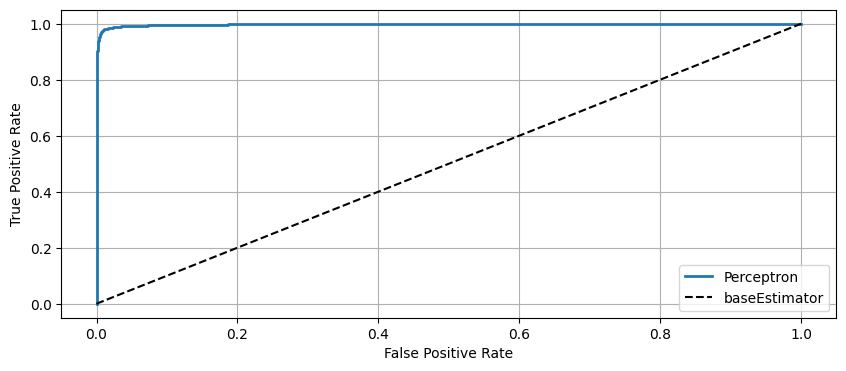

In [97]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_0, y_scores)
plt.figure(figsize=(10,4))
plt.plot(fpr, tpr, linewidth=2, label='Perceptron')
plt.plot([0, 1], [0, 1], 'k--',label='baseEstimator')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.legend()
plt.show()

### Warm Start VS Cold Start

#### Cold Start

In [98]:
bin_clf.fit(x_train,y_train_0)
y_hat_train_0 = bin_clf.predict(x_train)
print('Training Accuracy: ', bin_clf. score(x_train, y_train_0))
print('Test accuracy: ',bin_clf.score(x_test, y_test_0))

Training Accuracy:  0.99095
Test accuracy:  0.989


#### Warm Start

In [100]:
bin_clf_warm = Perceptron(max_iter=100, random_state=1729, warm_start=True)

bin_clf_warm.fit(x_train,y_train_0)
print('Training Accuracy: ', bin_clf_warm. score(x_train, y_train_0) )

Training Accuracy:  0.99095
